# TSTR Utility Evaluation

### Research question:
How much downstream predictive utility is preserved when classifiers are trained on synthetic data and evaluated on held-out real data?

**We compare**: Bootstrap vs. GMM vs. CVAE

across:
- HIV
- breast cancer
- diabetes

### Main comparison:
- TRTR: train on real, test on real
- TSTR: train on synthetic, test on real

# Imports and config

In [4]:
import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

from loaders import load_breast, load_diabetes, load_HIV
from models.bootstrap import sample_bootstrap
from models.gmm import sample_gmm
from models.cvae import train_cvae_on_arrays, sample_cvae_dataset

DATASETS = [load_HIV, load_breast, load_diabetes]
METHODS = ["bootstrap", "gmm", "cvae"]

FRACTIONS = [0.2, 0.3, 0.4, 0.5]
N_REPEATS = 10
TEST_SIZE = 0.30
CVAE_EPOCHS = 200
SEED = 42

OUTDIR = Path("../results_tstr")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Helper
- Balance samples
- Frac

In [1]:
def fraction_to_n(y, frac):
    n0 = max(2, int(np.floor((y == 0).sum() * frac)))
    n1 = max(2, int(np.floor((y == 1).sum() * frac)))
    return n0, n1


def stratified_subsample_xy(X, y, n0, n1, seed=42):
    rng = np.random.default_rng(seed)

    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]

    take0 = rng.choice(idx0, size=n0, replace=False)
    take1 = rng.choice(idx1, size=n1, replace=False)

    keep = np.concatenate([take0, take1])
    rng.shuffle(keep)

    return X[keep], y[keep]


def make_generator(method, X_train, y_train, n0, n1, seed=42, cvae_epochs=200):
    if method == "bootstrap":
        return sample_bootstrap(X_train, y_train, n0, n1, seed=seed)

    elif method == "gmm":
        return sample_gmm(X_train, y_train, n0, n1, seed=seed)

    elif method == "cvae":
        best = train_cvae_on_arrays(
            X_train,
            y_train,
            seed=seed,
            epochs=cvae_epochs,
            batch_size=32,
        )
        return sample_cvae_dataset(best, n0, n1, seed=seed)

    else:
        raise ValueError(f"Unknown method: {method}")


def fit_rf(X_train, y_train, seed=42):
    clf = RandomForestClassifier(
        n_estimators=200,
        random_state=seed,
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    return clf


def score_classifier(clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    return {"f1": f1, "auc": auc}

# One TSTR run

In [ ]:
def run_tstr_once(load_fn, frac=0.3, seed=42, test_size=0.3, cvae_epochs=200):
    data = load_fn()
    X = data["X"]
    y = data["y"]
    dataset_name = data["dataset"]

    # optional: reduce available real data first
    n0, n1 = fraction_to_n(y, frac)
    X_small, y_small = stratified_subsample_xy(X, y, n0, n1, seed=seed)

    # split real data into train/test
    X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
        X_small,
        y_small,
        test_size=test_size,
        stratify=y_small,
        random_state=seed,
    )

    # real baseline
    clf_real = fit_rf(X_train_real, y_train_real, seed=seed)
    trtr = score_classifier(clf_real, X_test_real, y_test_real)

    rows = []

    # size-match synthetic train data to real train data
    n0_train = int((y_train_real == 0).sum())
    n1_train = int((y_train_real == 1).sum())

    for method in METHODS:
        X_syn, y_syn = make_generator(
            method,
            X_train_real,
            y_train_real,
            n0=n0_train,
            n1=n1_train,
            seed=seed,
            cvae_epochs=cvae_epochs,
        )

        clf_syn = fit_rf(X_syn, y_syn, seed=seed)
        tstr = score_classifier(clf_syn, X_test_real, y_test_real)

        row = {
            "dataset": dataset_name,
            "frac": frac,
            "seed": seed,
            "method": method,
            "trtr_f1": trtr["f1"],
            "trtr_auc": trtr["auc"],
            "tstr_f1": tstr["f1"],
            "tstr_auc": tstr["auc"],
            "utility_gap_f1": trtr["f1"] - tstr["f1"],
            "utility_gap_auc": trtr["auc"] - tstr["auc"],
            "utility_ratio_f1": tstr["f1"] / trtr["f1"] if trtr["f1"] > 0 else np.nan,
            "utility_ratio_auc": tstr["auc"] / trtr["auc"] if trtr["auc"] > 0 else np.nan,
            "n_train_real": len(y_train_real),
            "n_test_real": len(y_test_real),
        }
        rows.append(row)

    return pd.DataFrame(rows)

# Run

In [9]:
all_rows = []

for load_fn in DATASETS:
    for frac in FRACTIONS:
        for seed in range(N_REPEATS):
            data = load_fn()
            print(f"Running {data['dataset']} | frac={frac} | seed={seed}")
            df_run = run_tstr_once(
                load_fn,
                frac=frac,
                seed=seed,
                test_size=TEST_SIZE,
                cvae_epochs=CVAE_EPOCHS,
            )
            all_rows.append(df_run)

df_tstr = pd.concat(all_rows, ignore_index=True)
df_tstr.head()

c:\Users\tonyt\Desktop\synthetic-data\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\tonyt\Desktop\synthetic-data\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Running HIV | frac=0.2 | seed=0
Epoch  50 | val loss=37.1570 recon=36.6201 kl=1.0739
Epoch 100 | val loss=39.8802 recon=38.9255 kl=1.9095
Epoch 150 | val loss=39.3560 recon=37.8952 kl=2.9215
Epoch 200 | val loss=35.9276 recon=34.4327 kl=2.9898


c:\Users\tonyt\Desktop\synthetic-data\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\tonyt\Desktop\synthetic-data\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Running HIV | frac=0.2 | seed=1
Epoch  50 | val loss=57.2752 recon=52.9133 kl=8.7237
Epoch 100 | val loss=54.5879 recon=51.8445 kl=5.4868
Epoch 150 | val loss=62.2373 recon=59.8487 kl=4.7773
Epoch 200 | val loss=63.1158 recon=60.7174 kl=4.7969


c:\Users\tonyt\Desktop\synthetic-data\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\tonyt\Desktop\synthetic-data\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

c:\Users\tonyt\Desktop\synthetic-data\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\tonyt\Desktop\synthetic-data\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Running HIV | frac=0.5 | seed=8
Epoch  50 | val loss=164.1917 recon=157.5918 kl=13.1999
Epoch 100 | val loss=150.1604 recon=141.1787 kl=17.9634
Epoch 150 | val loss=143.5869 recon=134.7202 kl=17.7333
Epoch 200 | val loss=140.6102 recon=131.7746 kl=17.6713


c:\Users\tonyt\Desktop\synthetic-data\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\tonyt\Desktop\synthetic-data\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Running HIV | frac=0.5 | seed=9
Epoch  50 | val loss=57.8479 recon=56.6365 kl=2.4228
Epoch 100 | val loss=52.5423 recon=50.6467 kl=3.7911
Epoch 150 | val loss=50.8618 recon=48.5565 kl=4.6107
Epoch 200 | val loss=48.6912 recon=45.9237 kl=5.5348
Running breast_cancer | frac=0.2 | seed=0
Epoch  50 | val loss=34.2518 recon=31.3483 kl=5.8070
Epoch 100 | val loss=29.1718 recon=25.7274 kl=6.8888
Epoch 150 | val loss=25.9973 recon=21.8676 kl=8.2593
Epoch 200 | val loss=22.7357 recon=18.4636 kl=8.5441
Running breast_cancer | frac=0.2 | seed=1
Epoch  50 | val loss=10.3164 recon=8.6841 kl=3.2646
Epoch 100 | val loss=9.9342 recon=7.8136 kl=4.2413
Epoch 150 | val loss=8.9116 recon=6.7775 kl=4.2683
Epoch 200 | val loss=8.4181 recon=6.1014 kl=4.6333
Running breast_cancer | frac=0.2 | seed=2
Epoch  50 | val loss=15.7598 recon=13.1097 kl=5.3002
Epoch 100 | val loss=12.1523 recon=9.1229 kl=6.0588
Epoch 150 | val loss=12.5242 recon=9.2523 kl=6.5438
Epoch 200 | val loss=11.2255 recon=7.9736 kl=6.5038
Runn

,dataset,frac,seed,method,trtr_f1,trtr_auc,tstr_f1,tstr_auc,utility_gap_f1,utility_gap_auc,utility_ratio_f1,utility_ratio_auc,n_train_real,n_test_real
0,HIV,0.2,0,bootstrap,0.888889,1.0,0.909091,0.6,-0.020202,0.4,1.022727,0.6,11,6
1,HIV,0.2,0,gmm,0.888889,1.0,0.750000,0.8,0.138889,0.2,0.843750,0.8,11,6
2,HIV,0.2,0,cvae,0.888889,1.0,0.500000,0.4,0.388889,0.6,0.562500,0.4,11,6
3,HIV,0.2,1,bootstrap,0.800000,0.8,0.909091,0.8,-0.109091,0.0,1.136364,1.0,11,6
4,HIV,0.2,1,gmm,0.800000,0.8,0.800000,0.8,0.000000,0.0,1.000000,1.0,11,6


In [ ]:
df_tstr.to_csv(OUTDIR / "tstr_results.csv", index=False)
print("Saved:", OUTDIR / "tstr_results.csv")

Saved: ..\results_tstr\tstr_results.csv


## Summmmmmmmmmmmmmmmmmmmurrrrrrrrrrrrrrrrrrrrize

In [ ]:
summary = (
    df_tstr.groupby(["dataset", "frac", "method"], as_index=False)
           .agg(
               tstr_f1_mean=("tstr_f1", "mean"),
               tstr_f1_sd=("tstr_f1", "std"),
               tstr_auc_mean=("tstr_auc", "mean"),
               tstr_auc_sd=("tstr_auc", "std"),
               trtr_f1_mean=("trtr_f1", "mean"),
               trtr_auc_mean=("trtr_auc", "mean"),
               utility_gap_f1_mean=("utility_gap_f1", "mean"),
               utility_gap_auc_mean=("utility_gap_auc", "mean"),
               utility_ratio_f1_mean=("utility_ratio_f1", "mean"),
               utility_ratio_auc_mean=("utility_ratio_auc", "mean"),
           )
)

summary

,dataset,frac,method,tstr_f1_mean,tstr_f1_sd,tstr_auc_mean,tstr_auc_sd,trtr_f1_mean,trtr_auc_mean,utility_gap_f1_mean,utility_gap_auc_mean,utility_ratio_f1_mean,utility_ratio_auc_mean
0,HIV,0.2,bootstrap,0.827850,0.179874,0.830000,0.221359,0.891941,0.900000,0.064091,0.070000,0.931941,0.916667
1,HIV,0.2,cvae,0.749084,0.161887,0.740000,0.231900,0.891941,0.900000,0.142857,0.160000,0.867311,0.858333
2,HIV,0.2,gmm,0.807460,0.209983,0.800000,0.249444,0.891941,0.900000,0.084481,0.100000,0.891264,0.868333
3,HIV,0.3,bootstrap,0.820443,0.140562,0.791667,0.232406,0.917283,0.920833,0.096840,0.129167,0.891380,0.852576
4,HIV,0.3,cvae,0.868998,0.095792,0.858333,0.184466,0.917283,0.920833,0.048285,0.062500,0.947941,0.921818
5,HIV,0.3,gmm,0.900616,0.049625,0.875000,0.181089,0.917283,0.920833,0.016667,0.045833,0.983076,0.942424
6,HIV,0.4,bootstrap,0.902138,0.058578,0.975000,0.040254,0.941046,0.983333,0.038908,0.008333,0.959598,0.993271
7,HIV,0.4,cvae,0.884969,0.104075,0.906250,0.130751,0.941046,0.983333,0.056076,0.077083,0.942693,0.923434
8,HIV,0.4,gmm,0.914065,0.085298,0.979167,0.052887,0.941046,0.983333,0.026981,0.004167,0.971263,0.995238
9,HIV,0.5,bootstrap,0.942205,0.066725,0.981818,0.032575,0.968737,0.987879,0.026532,0.006061,0.973430,0.994141


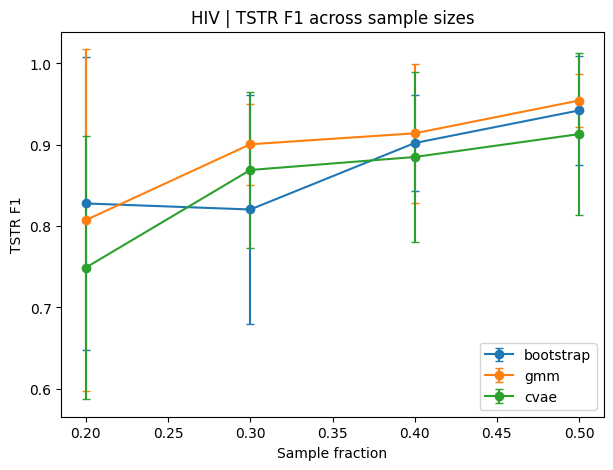

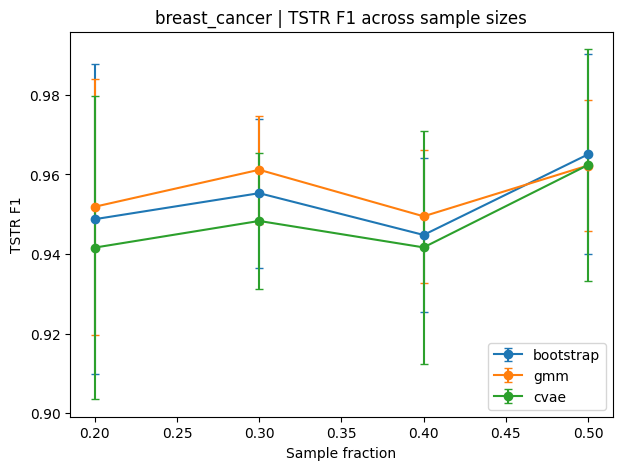

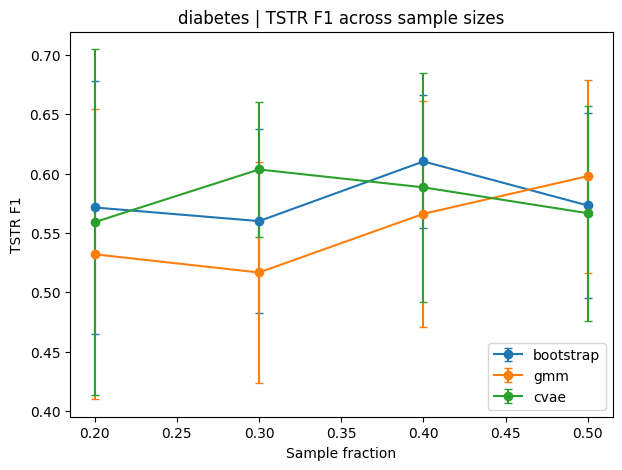

In [12]:
# %%
for ds_name in summary["dataset"].unique():
    sub = summary[summary["dataset"] == ds_name]

    fig, ax = plt.subplots(figsize=(7, 5))

    for method in METHODS:
        ss = sub[sub["method"] == method].sort_values("frac")
        ax.errorbar(
            ss["frac"],
            ss["tstr_f1_mean"],
            yerr=ss["tstr_f1_sd"],
            marker="o",
            capsize=3,
            label=method,
        )

    ax.set_title(f"{ds_name} | TSTR F1 across sample sizes")
    ax.set_xlabel("Sample fraction")
    ax.set_ylabel("TSTR F1")
    ax.legend()
    plt.show()

In [3]:
import matplotlib.pyplot as plt

# --- STEP 1: merge TSTR summary with RF AUC (distinguishability) ---

# Example: assuming you have rf_summary like:
# rf_summary columns: ["dataset", "frac", "method", "rf_auc_mean"]

merged = summary.merge(
    df_tstr,
    on=["dataset", "frac", "method"],
    how="inner"
)

# --- STEP 2: plot ---

for ds_name in merged["dataset"].unique():
    sub = merged[merged["dataset"] == ds_name]

    fig, ax = plt.subplots(figsize=(6, 5))

    for method in sub["method"].unique():
        ss = sub[sub["method"] == method]

        ax.scatter(
            ss["rf_auc_mean"],                 # distinguishability
            ss["tstr_f1_mean"],                # utility
            s=80,
            label=method
        )

        # annotate with sample size
        for _, r in ss.iterrows():
            ax.text(
                r["rf_auc_mean"],
                r["tstr_f1_mean"],
                f'{r["frac"]:.1f}',
                fontsize=8
            )

    ax.set_title(f"{ds_name} | Utility vs Distinguishability")
    ax.set_xlabel("RF AUC (distinguishability)")
    ax.set_ylabel("TSTR F1 (utility)")
    ax.legend()
    plt.show()

NameError: name 'summary' is not defined